In [1]:
import pandas as pd
import numpy as np


In [2]:
df=pd.read_csv('daily-minimum-temperatures-in-me.csv')

In [3]:
df.head()

,Date,Daily minimum temperatures
0,1/1/1981,20.7
1,1/2/1981,17.9
2,1/3/1981,18.8
3,1/4/1981,14.6
4,1/5/1981,15.8


In [4]:
df['Date']=pd.to_datetime(df['Date'])

In [5]:
df.sample()

,Date,Daily minimum temperatures
2942,1989-01-23,12.6


In [6]:
df.set_index('Date',inplace=True)

In [7]:
df

,Daily minimum temperatures
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8
...,...
1990-12-27,14
1990-12-28,13.6
1990-12-29,13.5


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3650 entries, 1981-01-01 to 1990-12-31
Data columns (total 1 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Daily minimum temperatures  3650 non-null   object
dtypes: object(1)
memory usage: 57.0+ KB


In [9]:
df.isnull().sum()

Daily minimum temperatures    0
dtype: int64

In [10]:
invalid_rows=df[~df['Daily minimum temperatures'].astype(str).str.isnumeric()]

In [11]:
invalid_rows

,Daily minimum temperatures
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8
...,...
1990-12-25,12.9
1990-12-26,14.6
1990-12-28,13.6


In [12]:
bad = df.loc[
    pd.to_numeric(df['Daily minimum temperatures'], errors='coerce').isna(),
    'Daily minimum temperatures'
]

print(bad)

Date
1982-07-20    ?0.2
1982-07-21    ?0.8
1984-07-14    ?0.1
Name: Daily minimum temperatures, dtype: object


In [13]:
df['Daily minimum temperatures']=df['Daily minimum temperatures'].str.replace("?","")

In [14]:
df['Daily minimum temperatures']=df['Daily minimum temperatures'].astype('float')

In [15]:
df.dtypes

Daily minimum temperatures    float64
dtype: object

<Axes: xlabel='Date'>

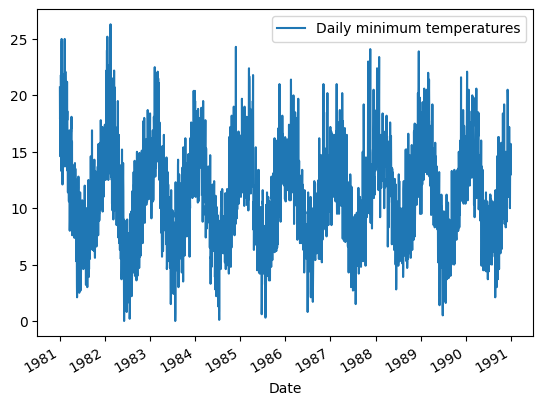

In [16]:
df.plot()

In [19]:
#check for stationarity

In [17]:
from statsmodels.tsa.stattools import adfuller,kpss

In [18]:
def adf_test(series):
    adf_test=adfuller(series)
    print(f"adf stats:{round(adf_test[0],3)}")
    print(f"p-value stats:{round(adf_test[1],3)}")
    print(f"lags values:{round(adf_test[2],3)}")
    for key,value in adf_test[4].items():
     print(f"{key}:{round(value,3)}")
        
def kpss_test(series):
    kpss_test=kpss(series,regression='ct')
    print("KPSS Statistic:", kpss_test[0])
    print("p-value:", kpss_test[1])
    print("Lags used:", kpss_test[2])
    print("Critical values:", kpss_test[3].items())

In [19]:
adf_test(df['Daily minimum temperatures'])

adf stats:-4.445
p-value stats:0.0
lags values:20
1%:-3.432
5%:-2.862
10%:-2.567


In [20]:
kpss_test(df['Daily minimum temperatures'])

KPSS Statistic: 0.049232800518522864
p-value: 0.1
Lags used: 36
Critical values: dict_items([('10%', 0.119), ('5%', 0.146), ('2.5%', 0.176), ('1%', 0.216)])


C:\Users\Mcc\AppData\Local\Temp\ipykernel_26184\448176768.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test=kpss(series,regression='ct')


In [25]:
#it indicates data is statinary

In [21]:
from statsmodels.graphics.tsaplots import plot_pacf,plot_acf

Figure(640x480)
Figure(640x480)


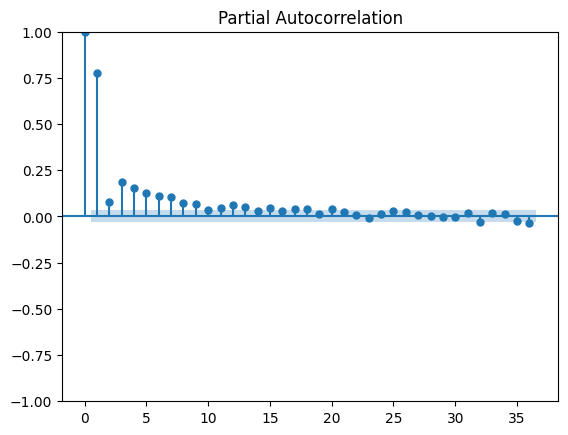

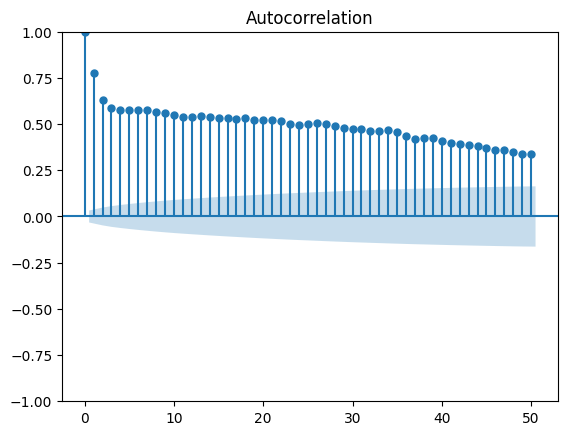

In [22]:
print(plot_pacf(df['Daily minimum temperatures']))
print(plot_acf(df['Daily minimum temperatures'],lags=50))

In [23]:
from scipy.stats import ks_2samp

In [24]:
first_half=df[:len(df)//2]
second_half=df[len(df)//2:]

In [25]:
first_half.shape

(1825, 1)

In [26]:
second_half.shape

(1825, 1)

In [27]:
stat, p_value = ks_2samp(first_half, second_half)

print(stat)
print(p_value)

# p-value	  Conclusion
# p < 0.05	  Reject H₀ → distributions are significantly different
# p >= 0.05	  Fail to reject H₀ → not enough evidence that they differ

[0.05205479]
[0.01422239]


In [28]:
if p_value<0.5:
    print('Reject H₀ → distributions are significantly different')
else:
    print('Fail to reject H₀ → not enough evidence that they differ')

Reject H₀ → distributions are significantly different


In [29]:
q_values=(np.arange(0,100,5))

In [30]:
train=df[:3600]
test=df[3600:]

In [113]:
test

,Daily minimum temperatures
Date,
1990-11-12,12.6
1990-11-13,13.8
1990-11-14,14.6
1990-11-15,13.2
1990-11-16,12.3
1990-11-17,8.8
1990-11-18,10.7
1990-11-19,9.9
1990-11-20,8.3


In [112]:
train

,Daily minimum temperatures
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8
...,...
1990-11-07,19.2
1990-11-08,15.4
1990-11-09,13.1


In [38]:
from statsmodels.tsa.arima.model import ARIMA

import warnings

warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt

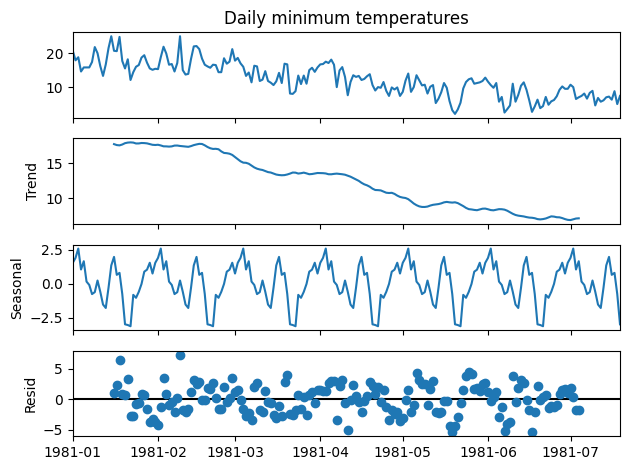

In [40]:
from statsmodels.tsa.seasonal import seasonal_decompose
result=seasonal_decompose(df['Daily minimum temperatures'].iloc[:200],model='additive',period=30)
result.plot()
plt.show()

In [41]:
#there is seasonality in data

In [35]:
q_value=np.arange(1,50,1)
for q in q_value:
    model=ARIMA(train['Daily minimum temperatures'],order=(12,0,q)).fit()
    print(q,"model -aic",model.aic,"model-bic",model.bic)



1 model -aic 16568.210060883965 model-bic 16661.04039775063
2 model -aic 16572.074667915873 model-bic 16671.09369390698
3 model -aic 16576.037919500723 model-bic 16681.245634616273
4 model -aic 16577.761912903632 model-bic 16689.15831714363
5 model -aic 16581.116269837847 model-bic 16698.701363202286
6 model -aic 16576.015385312792 model-bic 16699.789167801675
7 model -aic 16583.239084684803 model-bic 16713.201556298132
8 model -aic 16583.408508708602 model-bic 16719.559669446375
9 model -aic 16580.64070036589 model-bic 16722.980550228105
10 model -aic 16571.28546568111 model-bic 16719.814004667773
11 model -aic 16576.87451207237 model-bic 16731.591740183474
12 model -aic 16577.43507817018 model-bic 16738.340995405728
13 model -aic 16490.147590928133 model-bic 16657.242197288127
14 model -aic 16587.936265192104 model-bic 16761.21956067654


KeyboardInterrupt: 

In [42]:
model=ARIMA(train['Daily minimum temperatures'],order=(12,0,1)).fit()

In [43]:
residuals = model.resid

from statsmodels.stats.diagnostic import acorr_ljungbox

In [44]:
result = acorr_ljungbox(
    residuals,
    lags=[10],
    return_df=True
)
print(result)

     lb_stat  lb_pvalue
10  0.077447        1.0


In [45]:
pred = model.predict(
    start=len(train['Daily minimum temperatures']),
    end=len(df['Daily minimum temperatures'])-1
)

pred.index = test.index

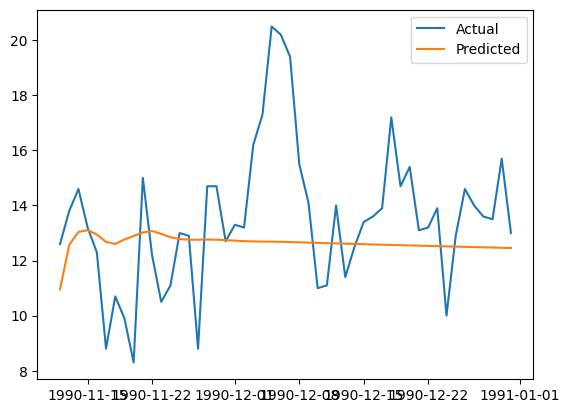

In [46]:
import matplotlib.pyplot as plt

plt.plot(test.index,test, label='Actual')
plt.plot(pred.index,pred, label='Predicted')
plt.legend()
plt.show()

In [47]:
from sklearn.metrics import mean_squared_error
np.sqrt(mean_squared_error(test,pred))

np.float64(2.7353550949667014)

In [48]:
pred_future=model.predict(start=len(df),end=len(df)+20,dynamic=False)

In [49]:
future_dates = pd.date_range(
    start=df.index[-1] + pd.Timedelta(days=1),
    periods=21,
    freq='D'
)

In [50]:
forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Forecast': pred_future
})

print(forecast_df)

           Date   Forecast
3650 1991-01-01  12.448962
3651 1991-01-02  12.440965
3652 1991-01-03  12.433033
3653 1991-01-04  12.425164
3654 1991-01-05  12.417355
3655 1991-01-06  12.409606
3656 1991-01-07  12.401917
3657 1991-01-08  12.394289
3658 1991-01-09  12.386721
3659 1991-01-10  12.379212
3660 1991-01-11  12.371762
3661 1991-01-12  12.364371
3662 1991-01-13  12.357036
3663 1991-01-14  12.349758
3664 1991-01-15  12.342537
3665 1991-01-16  12.335373
3666 1991-01-17  12.328264
3667 1991-01-18  12.321211
3668 1991-01-19  12.314212
3669 1991-01-20  12.307268
3670 1991-01-21  12.300378


In [85]:
# !pip install pmdarima

In [51]:
from pmdarima import auto_arima

In [52]:
train.shape

(3600, 1)

In [53]:
model = auto_arima(
    train['Daily minimum temperatures'],
    seasonal=True,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=16560.666, Time=2.48 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=20342.390, Time=0.05 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=17041.607, Time=0.28 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=18312.895, Time=0.38 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=28030.284, Time=0.04 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=16594.459, Time=1.53 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=16611.456, Time=2.51 sec
 ARIMA(3,0,2)(0,0,0)[0] intercept   : AIC=16558.644, Time=3.37 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=16556.655, Time=3.27 sec
 ARIMA(3,0,0)(0,0,0)[0] intercept   : AIC=16890.667, Time=0.72 sec
 ARIMA(4,0,1)(0,0,0)[0] intercept   : AIC=16558.643, Time=3.63 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=17022.640, Time=0.48 sec
 ARIMA(4,0,0)(0,0,0)[0] intercept   : AIC=16807.032, Time=0.91 sec
 ARIMA(4,0,2)(0,0,0)[0] intercept   : AIC=16560.564, Time=2.13 sec
 ARIMA(3,0,1)(0,0,0

In [54]:
print("Best model:", model.order)

print(model.summary())

Best model: (3, 0, 1)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 3600
Model:               SARIMAX(3, 0, 1)   Log Likelihood               -8272.327
Date:                Thu, 27 Aug 2026   AIC                          16556.655
Time:                        22:29:31   BIC                          16593.787
Sample:                             0   HQIC                         16569.888
                               - 3600                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0565      0.018      3.112      0.002       0.021       0.092
ar.L1          1.4842      0.019     79.738      0.000       1.448       1.521
ar.L2         -0.6218      0.0

In [55]:
start=len(train['Daily minimum temperatures'])
end=len(df['Daily minimum temperatures'])-1
print(start,end)

3600 3649


In [56]:
pred = model.predict(n_periods=len(test))
pred.index=test.index
pred

Date
1990-11-12    10.912604
1990-11-13    12.430986
1990-11-14    12.861970
1990-11-15    12.864292
1990-11-16    12.801166
1990-11-17    12.763197
1990-11-18    12.746402
1990-11-19    12.736711
1990-11-20    12.727733
1990-11-21    12.718206
1990-11-22    12.708364
1990-11-23    12.698488
1990-11-24    12.688687
1990-11-25    12.678975
1990-11-26    12.669345
1990-11-27    12.659791
1990-11-28    12.650310
1990-11-29    12.640902
1990-11-30    12.631566
1990-12-01    12.622302
1990-12-02    12.613109
1990-12-03    12.603988
1990-12-04    12.594936
1990-12-05    12.585954
1990-12-06    12.577042
1990-12-07    12.568197
1990-12-08    12.559422
1990-12-09    12.550713
1990-12-10    12.542072
1990-12-11    12.533497
1990-12-12    12.524989
1990-12-13    12.516545
1990-12-14    12.508167
1990-12-15    12.499854
1990-12-16    12.491604
1990-12-17    12.483418
1990-12-18    12.475295
1990-12-19    12.467234
1990-12-20    12.459236
1990-12-21    12.451299
1990-12-22    12.443424
1990-12-23 

In [57]:
len(test.index),len(pred)

(50, 50)

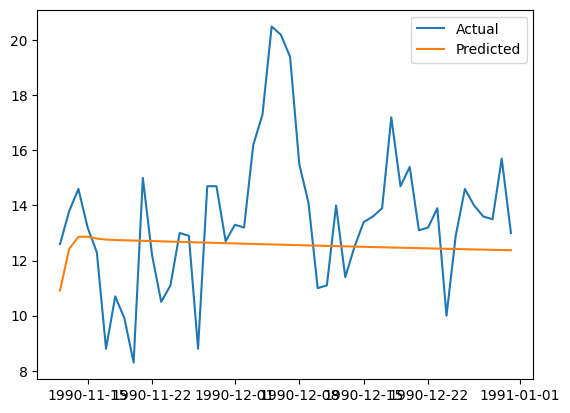

In [58]:
import matplotlib.pyplot as plt

plt.plot(test, label='Actual')
plt.plot(pred, label='Predicted')
plt.legend()
plt.show()

In [59]:
from sklearn.metrics import mean_squared_error
np.sqrt(mean_squared_error(test,pred))

np.float64(2.7742843745594468)

In [60]:
pred_future = model.predict(n_periods=21) #how many days to predict it n_periods

len(pred_future)

21

In [61]:
future_dates = pd.date_range(
    start=df.index[-1] + pd.Timedelta(days=1),
    periods=21,
    freq='D'
)
future_dates
len(future_dates)

21

In [62]:
print(type(pred_future))
print(pred_future.shape)
print(type(future_dates))

<class 'pandas.core.series.Series'>
(21,)
<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


In [63]:
pred_future.index = future_dates

print(pred_future)

1991-01-01    10.912604
1991-01-02    12.430986
1991-01-03    12.861970
1991-01-04    12.864292
1991-01-05    12.801166
1991-01-06    12.763197
1991-01-07    12.746402
1991-01-08    12.736711
1991-01-09    12.727733
1991-01-10    12.718206
1991-01-11    12.708364
1991-01-12    12.698488
1991-01-13    12.688687
1991-01-14    12.678975
1991-01-15    12.669345
1991-01-16    12.659791
1991-01-17    12.650310
1991-01-18    12.640902
1991-01-19    12.631566
1991-01-20    12.622302
1991-01-21    12.613109
Freq: D, dtype: float64
